# Handwritten Character Recognition using CNN

## Project Objective

The objective of this project is to recognize handwritten digits
using image processing and a Convolutional Neural Network (CNN).

## Dataset

The MNIST handwritten digit dataset is used for training and testing.

## Technologies Used

- Python
- TensorFlow
- Keras
- NumPy
- Matplotlib
- Scikit-learn

## Model

A Convolutional Neural Network (CNN) is used to classify handwritten
digits from 0 to 9.


In [24]:
## 1. Import Libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


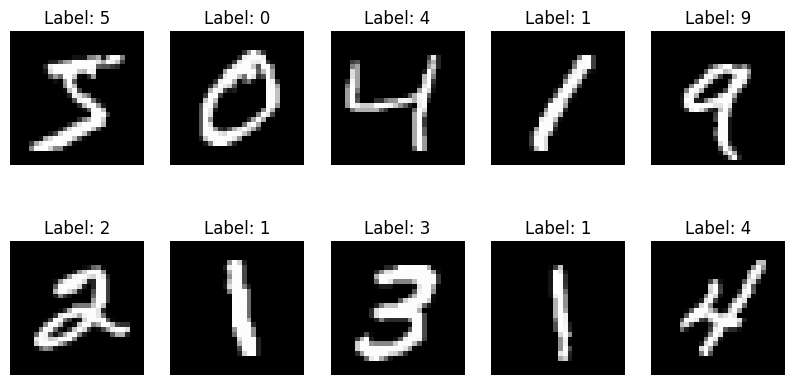

In [3]:
# Display some handwritten digit images

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.show()

In [4]:
# Normalize pixel values

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [5]:
# Reshape images for CNN

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (60000, 28, 28, 1)
Testing data shape: (10000, 28, 28, 1)


In [6]:
# Build CNN model

model = tf.keras.Sequential([

    # Convolutional layer
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    # Pooling layer
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Second convolutional layer
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Second pooling layer
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convert feature maps into one-dimensional vector
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(128, activation="relu"),

    # Output layer - 10 digits
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Compile the CNN model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [8]:
# Train the model

history = model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 53ms/step - accuracy: 0.9501 - loss: 0.1708 - val_accuracy: 0.9825 - val_loss: 0.0656
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.9836 - loss: 0.0519 - val_accuracy: 0.9870 - val_loss: 0.0415
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.9889 - loss: 0.0359 - val_accuracy: 0.9900 - val_loss: 0.0385
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 50ms/step - accuracy: 0.9920 - loss: 0.0253 - val_accuracy: 0.9887 - val_loss: 0.0386
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 49ms/step - accuracy: 0.9933 - loss: 0.0207 - val_accuracy: 0.9897 - val_loss: 0.0391


In [9]:
# Evaluate the model on test data

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=2
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

313/313 - 3s - 9ms/step - accuracy: 0.9880 - loss: 0.0351
Test Loss: 0.03507446125149727
Test Accuracy: 0.9879999756813049
Test Accuracy (%): 98.7999975681305


In [10]:
# Make predictions on test images

predictions = model.predict(x_test)

print("Prediction probabilities shape:", predictions.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Prediction probabilities shape: (10000, 10)


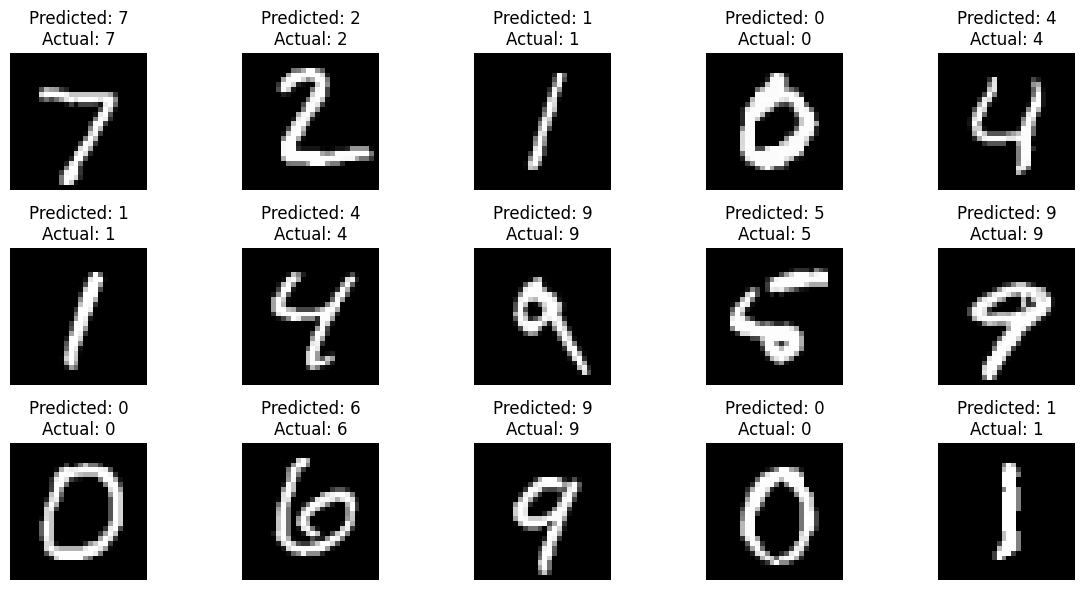

In [11]:
# Display predictions

plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")

    predicted_label = np.argmax(predictions[i])
    actual_label = y_test[i]

    plt.title(
        f"Predicted: {predicted_label}\nActual: {actual_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
# Find incorrectly predicted images

predicted_labels = np.argmax(predictions, axis=1)

incorrect_indices = np.where(
    predicted_labels != y_test
)[0]

print("Number of incorrect predictions:", len(incorrect_indices))

Number of incorrect predictions: 120


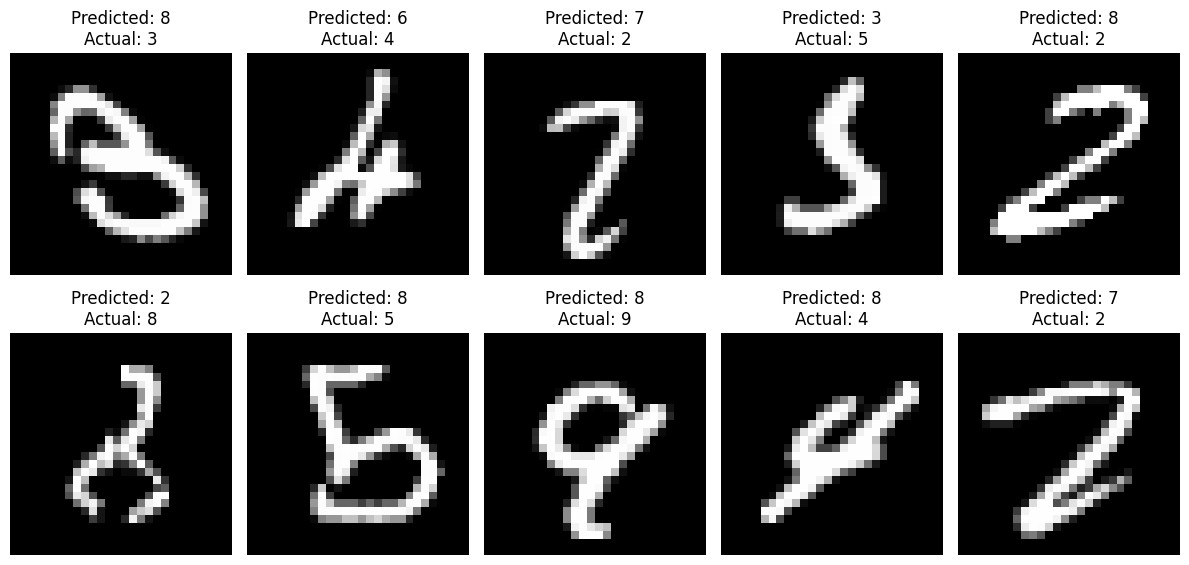

In [13]:
# Display some incorrect predictions

plt.figure(figsize=(12, 6))

for i, index in enumerate(incorrect_indices[:10]):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        x_test[index].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Predicted: {predicted_labels[index]}\n"
        f"Actual: {y_test[index]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

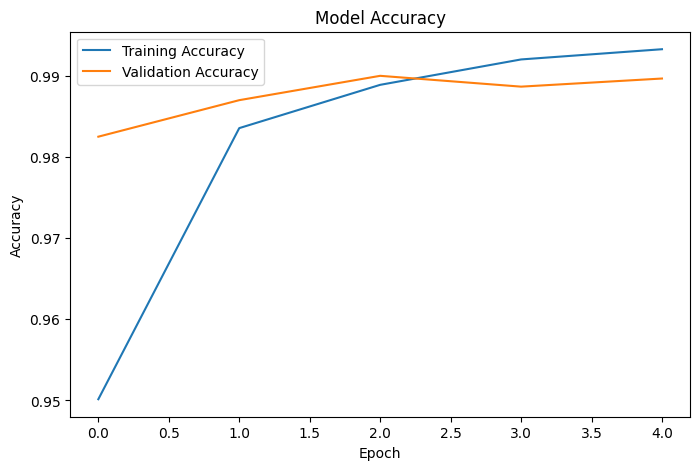

In [14]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

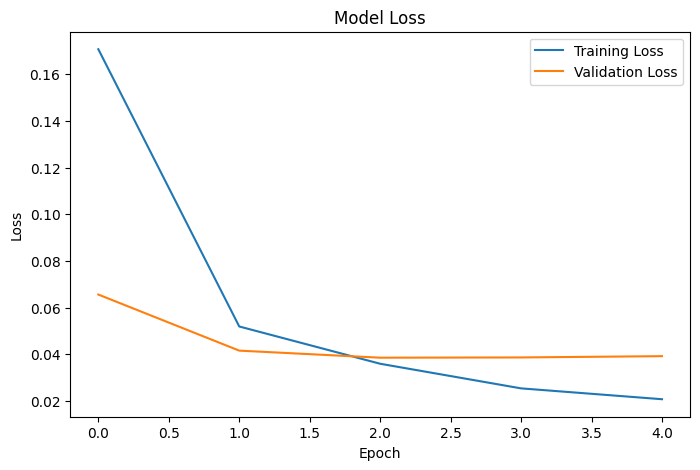

In [15]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [16]:
# Save the trained model

model.save("handwritten_character_recognition.keras")

print("Model saved successfully!")

Model saved successfully!


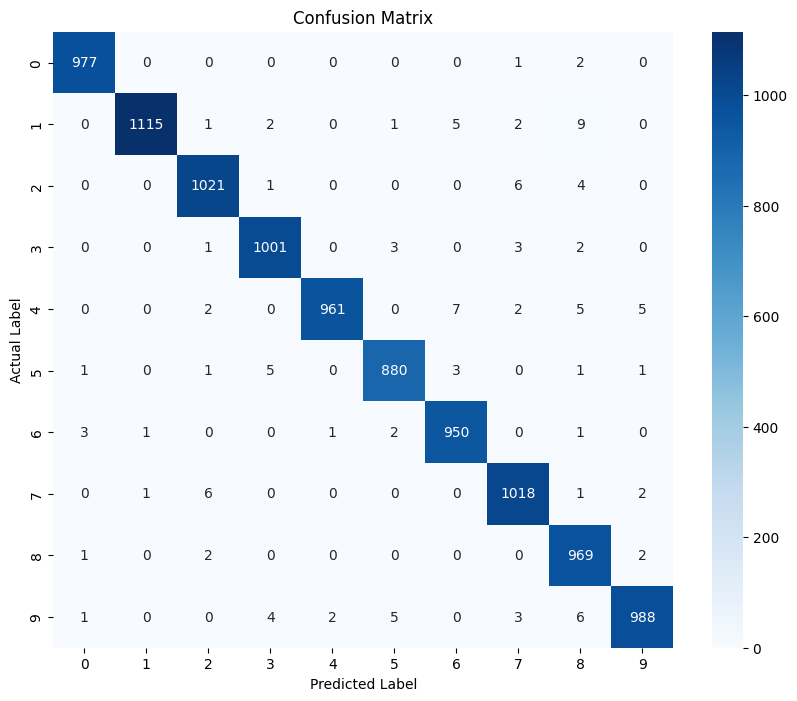

In [17]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [18]:
# Classification Report

from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    predicted_labels
)

print(report)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       1.00      0.98      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0.98      0.99       982
           5       0.99      0.99      0.99       892
           6       0.98      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.97      0.99      0.98       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



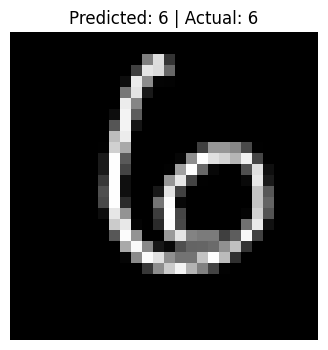

In [19]:
# Test a single handwritten image

index = 100

image = x_test[index]
actual_digit = y_test[index]

prediction = model.predict(
    image.reshape(1, 28, 28, 1),
    verbose=0
)

predicted_digit = np.argmax(prediction)

plt.figure(figsize=(4, 4))
plt.imshow(image.reshape(28, 28), cmap="gray")

plt.title(
    f"Predicted: {predicted_digit} | Actual: {actual_digit}"
)

plt.axis("off")
plt.show()

In [20]:
# Prediction confidence

confidence = np.max(prediction) * 100

print("Predicted Digit:", predicted_digit)
print("Confidence: {:.2f}%".format(confidence))
print("Actual Digit:", actual_digit)

Predicted Digit: 6
Confidence: 100.00%
Actual Digit: 6


In [21]:
# Save trained model

model.save("handwritten_character_recognition.keras")

print("Model saved successfully!")

Model saved successfully!


In [22]:
# Final Project Results

print("=" * 50)
print("HANDWRITTEN CHARACTER RECOGNITION")
print("=" * 50)

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"Incorrect Predictions: {len(incorrect_indices)}")
print(f"Correct Predictions: {len(y_test) - len(incorrect_indices)}")

print("=" * 50)

HANDWRITTEN CHARACTER RECOGNITION
Test Accuracy: 98.80%
Test Loss: 0.0351
Incorrect Predictions: 120
Correct Predictions: 9880
